# coroutines_vs_threads — notebook

Optional CMake build, then two benchmark runs. Each run compares **threads vs coroutines** with three plots per run: linear, log-X linear-Y, and log-log (throughput in KOps/s).

## 1. Constants

Set shared values used by all runs. **`DEPS_PREFIX`** is defined once here (override with env `TPCC_DEPS_PREFIX`).

**Run this cell first** so `DEPS_PREFIX`, `RUN_BUILD`, ranges, pool size, and optional `CGROUP_TASKS_FILE` are available to later sections.

In [ ]:
import os

RUN_BUILD = False

# fbcode getdeps installed/ root (cmake -DDEPS_PREFIX=...). Override with env TPCC_DEPS_PREFIX.
_DEPS_PREFIX_DEFAULT = "/tmp/fbcode_builder_getdeps-ZhomeZeivanov89ZpackagesZfollyZbuildZfbcode_builder/installed"
DEPS_PREFIX = os.environ.get("TPCC_DEPS_PREFIX", _DEPS_PREFIX_DEFAULT)

# cgroup v2: full path to cgroup.procs (or v1 cpuset tasks). Empty = do not attach benchmark PIDs.
# Moving tasks from a root-owned cgroup (e.g. ssh.service) may require sudo on the write; chown on the
# destination file alone is not enough — the kernel checks detach permission from the source cgroup.
CGROUP_TASKS_FILE = ""

# Shared range/pool for all runs.
FROM_N = 1
TO_N = 8192
SLICE_US_1 = 10
SLICE_US_2 = 1
POOL_SIZE = 32

# Directory for per-run JSON result files.  Empty string = do not save.
LOG_DIR = "logs"

## 2. Build (optional)

Set **`RUN_BUILD = True` in the Constants cell** to configure and build `coroutines_vs_threads`. `DEPS_PREFIX` comes from that cell (or env `TPCC_DEPS_PREFIX`).

In [29]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

try:
    DEPS_PREFIX
    RUN_BUILD
except NameError as e:
    raise RuntimeError(
        "Run the Constants cell (section 1) first so DEPS_PREFIX and RUN_BUILD are defined."
    ) from e

def find_repo_root() -> Path:
    """Walk up from cwd until we see this repo's CMakeLists + benchmark dir."""
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "CMakeLists.txt").is_file() and (p / "src" / "coroutines_vs_threads" / "main.cpp").is_file():
            return p
        p = p.parent
    raise RuntimeError(
        "Could not find tpcc repo root from cwd; open the notebook from the repo or set REPO_ROOT below."
    )


REPO_ROOT = find_repo_root()
BUILD_DIR = REPO_ROOT / "build"
CMAKE_BUILD_TYPE = "Release"

LIBPQXX_DIR = os.environ.get("TPCC_LIBPQXX_DIR", str(Path.home() / "packages" / "libpqxx" / "build"))
SPDLOG_DIR = os.environ.get("TPCC_SPDLOG_DIR", str(Path.home() / "packages" / "spdlog" / "build"))

if RUN_BUILD:
    BUILD_DIR.mkdir(parents=True, exist_ok=True)
    cmake_cmd = [
        "cmake",
        "-S",
        str(REPO_ROOT),
        "-B",
        str(BUILD_DIR),
        f"-DCMAKE_BUILD_TYPE={CMAKE_BUILD_TYPE}",
        f"-DDEPS_PREFIX={DEPS_PREFIX}",
        f"-Dlibpqxx_DIR={LIBPQXX_DIR}",
        f"-Dspdlog_DIR={SPDLOG_DIR}",
    ]
    print("Running:", " ".join(cmake_cmd))
    subprocess.run(cmake_cmd, check=True)
    subprocess.run(
        ["cmake", "--build", str(BUILD_DIR), "--target", "coroutines_vs_threads", "-j", str(os.cpu_count() or 4)],
        check=True,
    )
    print("Build OK:", BUILD_DIR / "coroutines_vs_threads")
else:
    print("RUN_BUILD is False — skipping CMake. Using BINARY from the next cell.")

RUN_BUILD is False — skipping CMake. Using BINARY from the next cell.


## 3. Shared: binary path & helpers

JSON results come from **stdout**; progress stays on **stderr**.

Run the **Constants** cell first (`CGROUP_TASKS_FILE` and paths). If you did **not** run the Build cell, this cell still sets `BUILD_DIR` by locating the repo from the current working directory (same logic as the Build cell).

**Re-run this cell** after editing it so definitions like `plot_threads_vs_coro_logx` and `plot_slice_compare_loglog` are loaded in the kernel.

In [30]:
import json
import os
import resource
import shlex
import shutil
import subprocess
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt

STACK_SIZE_KIB = 512

def _set_stack_limit() -> None:
    """preexec_fn: set RLIMIT_STACK before exec so benchmark threads get a smaller stack."""
    limit_bytes = STACK_SIZE_KIB * 1024
    resource.setrlimit(resource.RLIMIT_STACK, (limit_bytes, limit_bytes))

# If you skipped the Build cell, discover repo root the same way and set build dir.
try:
    BUILD_DIR
except NameError:
    def _find_repo_root() -> Path:
        p = Path.cwd().resolve()
        for _ in range(8):
            if (p / "CMakeLists.txt").is_file() and (
                p / "src" / "coroutines_vs_threads" / "main.cpp"
            ).is_file():
                return p
            p = p.parent
        raise RuntimeError(
            "BUILD_DIR is not set and repo root was not found from cwd. "
            "Run the Build cell above, or set BUILD_DIR = Path('.../build') here."
        )

    REPO_ROOT = _find_repo_root()
    BUILD_DIR = REPO_ROOT / "build"

# Default binary next to a normal in-tree build/
BINARY = BUILD_DIR / "coroutines_vs_threads"
if not BINARY.is_file():
    raise FileNotFoundError(
        f"Binary not found: {BINARY}\n"
        "Build with RUN_BUILD=True above or set BINARY to your executable path."
    )

# Set in Constants cell; empty string = do not attach to a cgroup.
try:
    CGROUP_TASKS_FILE
except NameError:
    CGROUP_TASKS_FILE = ""

_CGROUP_FS = Path("/sys/fs/cgroup").resolve()


def _cgroup_tasks_path() -> Optional[Path]:
    s = CGROUP_TASKS_FILE.strip()
    if not s:
        return None
    p = Path(s).expanduser()
    if not p.is_absolute():
        raise RuntimeError("CGROUP_TASKS_FILE must be an absolute path")
    return p.resolve()


def _assert_cgroup_usable() -> None:
    procs = _cgroup_tasks_path()
    if procs is None:
        return
    try:
        procs.relative_to(_CGROUP_FS)
    except ValueError:
        raise RuntimeError(
            f"CGROUP_TASKS_FILE must be under {_CGROUP_FS}, got: {procs}"
        )
    cgdir = procs.parent
    if not cgdir.is_dir():
        raise RuntimeError(
            f"cgroup directory does not exist: {cgdir}\n"
            "Fix CGROUP_TASKS_FILE or create the cgroup."
        )
    if not procs.exists():
        raise RuntimeError(f"cgroup tasks file does not exist: {procs}")
    if shutil.which("sudo") is None:
        raise RuntimeError(
            "CGROUP_TASKS_FILE is set but 'sudo' was not found in PATH; "
            "attaching the benchmark uses: echo $$ | sudo -n tee <cgroup.procs>"
        )


def run_benchmark(
    *,
    from_n: int,
    to_n: int,
    slice_us: int,
    pool_size: int,
    coro: bool,
    json_res_file: Optional[str] = None,
) -> dict:
    cmd = [
        str(BINARY),
        f"--from={from_n}",
        f"--to={to_n}",
        f"--slice_us={slice_us}",
        "--format=json",
    ]
    if coro:
        cmd.append("--coro")
        cmd.append(f"--pool_size={pool_size}")
    if json_res_file:
        cmd.append(f"--json_res_file={json_res_file}")

    if CGROUP_TASKS_FILE.strip():
        _assert_cgroup_usable()
        procs = _cgroup_tasks_path()
        assert procs is not None
        # Cross-cgroup attach needs privilege on the source cgroup; fail fast if sudo would prompt.
        shell_line = (
            f"echo $$ | sudo -n tee {shlex.quote(str(procs))} >/dev/null && exec {shlex.join(cmd)}"
        )
        run_cmd: list[str] = ["/bin/sh", "-c", shell_line]
        proc = subprocess.run(run_cmd, capture_output=True, text=True, preexec_fn=_set_stack_limit)
    else:
        run_cmd = cmd
        proc = subprocess.run(cmd, capture_output=True, text=True, preexec_fn=_set_stack_limit)

    if proc.returncode != 0:
        print(proc.stderr, file=sys.stderr)
        raise subprocess.CalledProcessError(proc.returncode, run_cmd, proc.stdout, proc.stderr)
    return json.loads(proc.stdout)


def _log_path(run_tag: str, mode: str, slice_us: int) -> Optional[str]:
    """Build a JSON result file path if LOG_DIR is set, else return None."""
    try:
        log_dir = LOG_DIR
    except NameError:
        return None
    if not log_dir:
        return None
    d = Path(log_dir)
    d.mkdir(parents=True, exist_ok=True)
    return str(d / f"{run_tag}_{mode}_slice{slice_us}us.json")


def series_kops(payload: dict) -> tuple[list[float], list[float]]:
    """X = concurrency, Y = KOps/s."""
    xs = [float(r["inflight"]) for r in payload["results"]]
    ys = [float(r["ops_per_sec"]) / 1000.0 for r in payload["results"]]
    return xs, ys


def _plot_threads_vs_coro(
    j_threads: dict,
    j_coro: dict,
    *,
    title: str,
    logx: bool,
    logy: bool,
) -> None:
    tx, ty = series_kops(j_threads)
    cx, cy = series_kops(j_coro)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(tx, ty, marker="o", label="threads")
    ax.plot(cx, cy, marker="s", label="coroutines")
    ax.set_xlabel("Concurrency (inflight)")
    ax.set_ylabel("Throughput (KOps/s)")
    if logx and logy:
        suffix = " — log X & Y"
    elif logx:
        suffix = " — log X"
    else:
        suffix = ""
    ax.set_title(title + suffix)
    if logx:
        ax.set_xscale("log", base=2)
        all_x = [x for x in tx + cx if x > 0]
        if all_x:
            lo, hi = min(all_x), max(all_x)
            ax.set_xlim(left=lo * 0.8, right=hi * 1.2)
    else:
        ax.set_xlim(left=0)
    if logy:
        ax.set_yscale("log")
        all_y = [y for y in ty + cy if y > 0]
        if all_y:
            lo, hi = min(all_y), max(all_y)
            ax.set_ylim(bottom=lo * 0.8, top=hi * 1.2)
    else:
        ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, alpha=0.3, which="both" if logx or logy else "major")
    plt.tight_layout()
    plt.show()


def plot_threads_vs_coro(j_threads: dict, j_coro: dict, *, title: str) -> None:
    """Linear X from 0, Y = KOps/s from 0."""
    _plot_threads_vs_coro(j_threads, j_coro, title=title, logx=False, logy=False)


def plot_threads_vs_coro_logx_liny(j_threads: dict, j_coro: dict, *, title: str) -> None:
    """Log-scale X, linear Y — best single-chart view for scaling + degradation."""
    _plot_threads_vs_coro(j_threads, j_coro, title=title, logx=True, logy=False)


def plot_threads_vs_coro_logx(j_threads: dict, j_coro: dict, *, title: str) -> None:
    """Same data as plot_threads_vs_coro but log-scale X and Y."""
    _plot_threads_vs_coro(j_threads, j_coro, title=title, logx=True, logy=True)


def series_wall_time(payload: dict) -> tuple[list[float], list[float]]:
    """X = concurrency, Y = wall time in seconds."""
    xs = [float(r["inflight"]) for r in payload["results"]]
    ys = [float(r["wall_time_s"]) for r in payload["results"]]
    return xs, ys


def plot_wall_time(
    j_threads: dict,
    j_coro: dict,
    *,
    title: str,
) -> None:
    """Wall time (seconds) vs concurrency, log-x."""
    tx, ty = series_wall_time(j_threads)
    cx, cy = series_wall_time(j_coro)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(tx, ty, marker="o", label="threads")
    ax.plot(cx, cy, marker="s", label="coroutines")
    ax.set_xlabel("Concurrency (inflight)")
    ax.set_ylabel("Wall time (s)")
    ax.set_title(title)
    ax.set_xscale("log", base=2)
    all_x = [x for x in tx + cx if x > 0]
    if all_x:
        lo, hi = min(all_x), max(all_x)
        ax.set_xlim(left=lo * 0.8, right=hi * 1.2)
    ax.set_ylim(bottom=0)
    ax.legend()
    ax.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


_MARKERS = ["o", "s", "^", "D", "v", "P"]


def plot_slice_compare_loglog(
    series: list[tuple[dict, str]],
    *,
    title: str,
) -> None:
    """Log-log: N runs (same mode), different slice_us."""
    fig, ax = plt.subplots(figsize=(9, 5))
    all_x: list[float] = []
    all_y: list[float] = []
    for i, (payload, label) in enumerate(series):
        xs, ys = series_kops(payload)
        ax.plot(xs, ys, marker=_MARKERS[i % len(_MARKERS)], label=label)
        all_x.extend(x for x in xs if x > 0)
        all_y.extend(y for y in ys if y > 0)
    ax.set_xlabel("Concurrency (inflight)")
    ax.set_ylabel("Throughput (KOps/s)")
    ax.set_title(title + " — log X & Y")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    if all_x:
        lo, hi = min(all_x), max(all_x)
        ax.set_xlim(left=lo * 0.8, right=hi * 1.2)
    if all_y:
        lo, hi = min(all_y), max(all_y)
        ax.set_ylim(bottom=lo * 0.8, top=hi * 1.2)
    ax.legend()
    ax.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

## 4. Run 1

Uses **`FROM_N`**, **`TO_N`**, **`SLICE_US_1`**, **`POOL_SIZE`** from Constants. Produces linear and log-log comparison plots.

In [31]:
try:
    FROM_N
    TO_N
    SLICE_US_1
    POOL_SIZE
except NameError as e:
    raise RuntimeError("Run the Constants cell (section 1) first.") from e

j1_threads = run_benchmark(
    from_n=FROM_N,
    to_n=TO_N,
    slice_us=SLICE_US_1,
    pool_size=POOL_SIZE,
    coro=False,
    json_res_file=_log_path("run1", "threads", SLICE_US_1),
)
j1_coro = run_benchmark(
    from_n=FROM_N,
    to_n=TO_N,
    slice_us=SLICE_US_1,
    pool_size=POOL_SIZE,
    coro=True,
    json_res_file=_log_path("run1", "coro", SLICE_US_1),
)

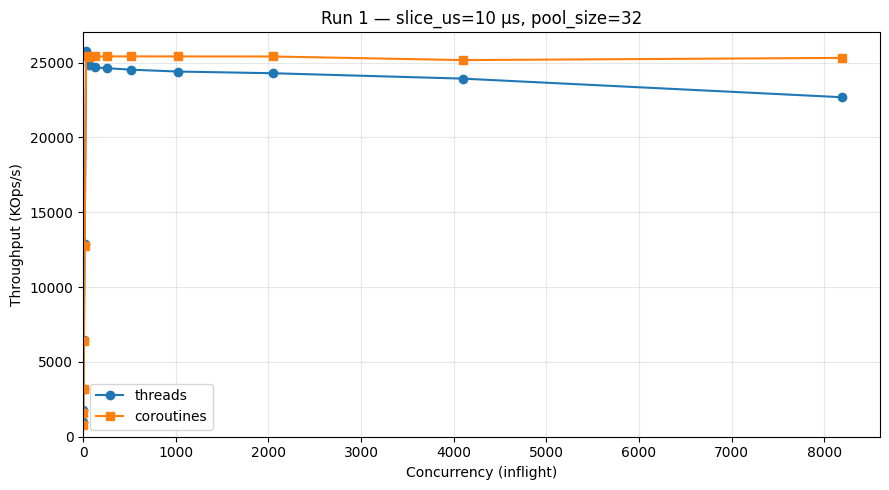

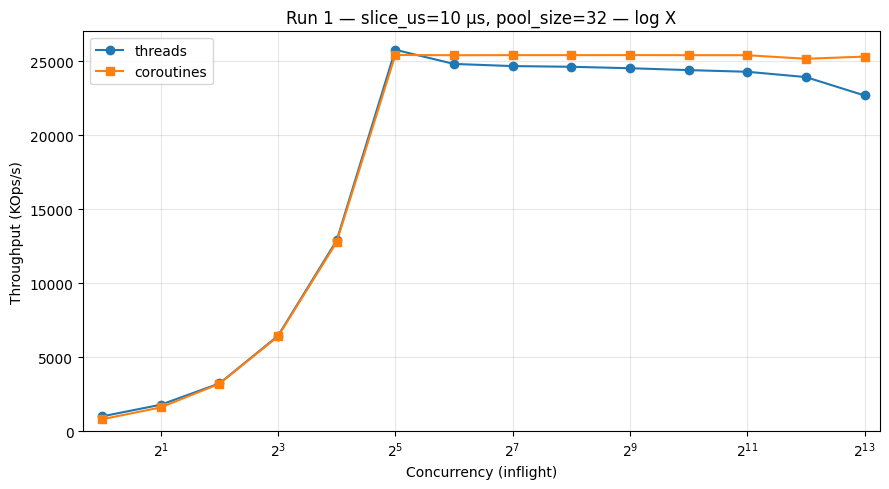

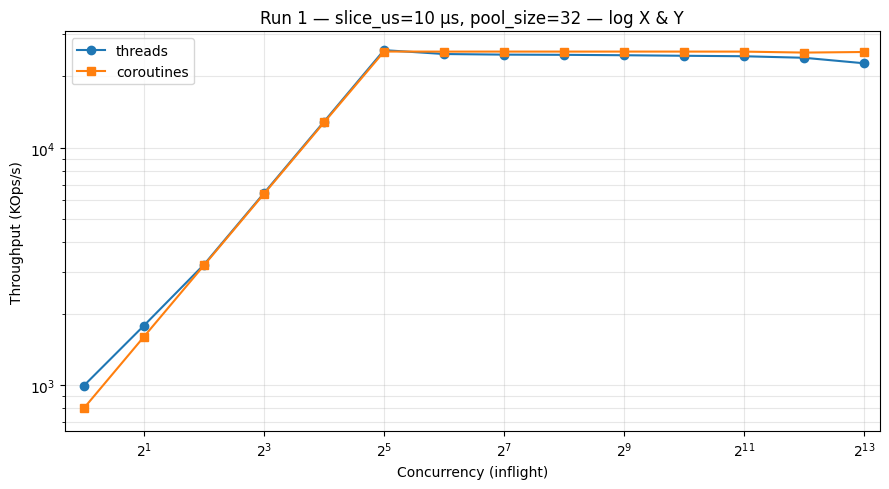

In [32]:
plot_threads_vs_coro(
    j1_threads,
    j1_coro,
    title=f"Run 1 — slice_us={SLICE_US_1} µs, pool_size={POOL_SIZE}",
)
plot_threads_vs_coro_logx_liny(
    j1_threads,
    j1_coro,
    title=f"Run 1 — slice_us={SLICE_US_1} µs, pool_size={POOL_SIZE}",
)
plot_threads_vs_coro_logx(
    j1_threads,
    j1_coro,
    title=f"Run 1 — slice_us={SLICE_US_1} µs, pool_size={POOL_SIZE}",
)

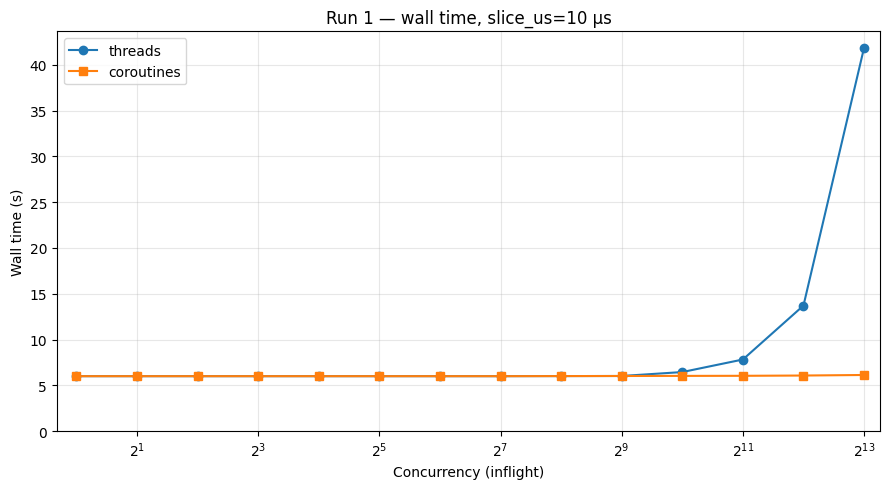

In [33]:
plot_wall_time(
    j1_threads,
    j1_coro,
    title=f"Run 1 — wall time, slice_us={SLICE_US_1} µs",
)

## 5. Run 2

Uses **`FROM_N`**, **`TO_N`**, **`SLICE_US_2`**, **`POOL_SIZE`** from Constants. Produces the same linear and log-log plots.

In [34]:
j2_threads = run_benchmark(
    from_n=FROM_N,
    to_n=TO_N,
    slice_us=SLICE_US_2,
    pool_size=POOL_SIZE,
    coro=False,
    json_res_file=_log_path("run2", "threads", SLICE_US_2),
)

j2_coro = run_benchmark(
    from_n=FROM_N,
    to_n=TO_N,
    slice_us=SLICE_US_2,
    pool_size=POOL_SIZE,
    coro=True,
    json_res_file=_log_path("run2", "coro", SLICE_US_2),
)

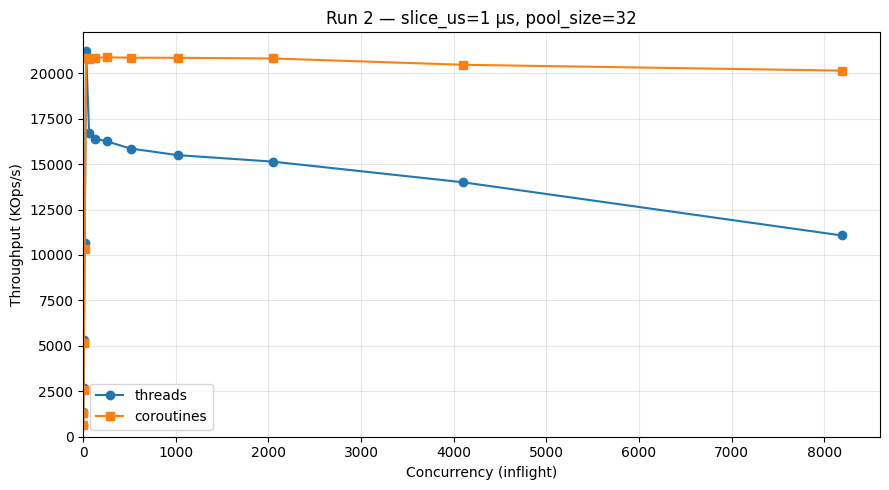

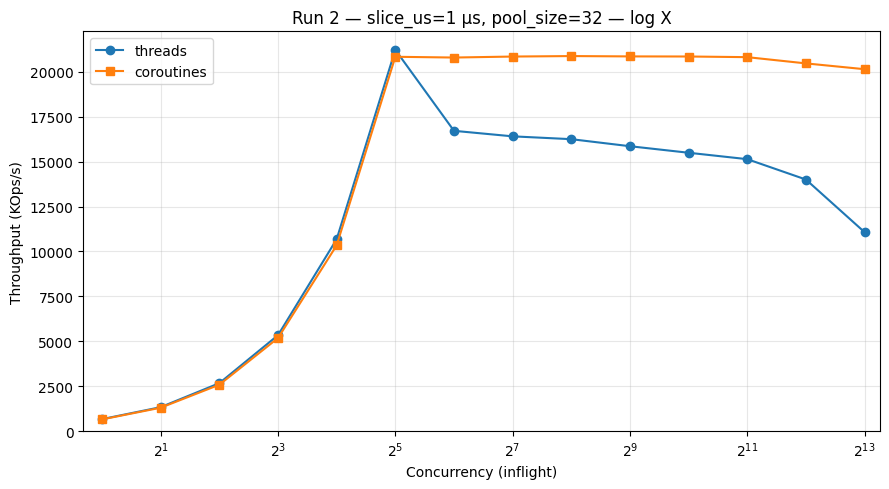

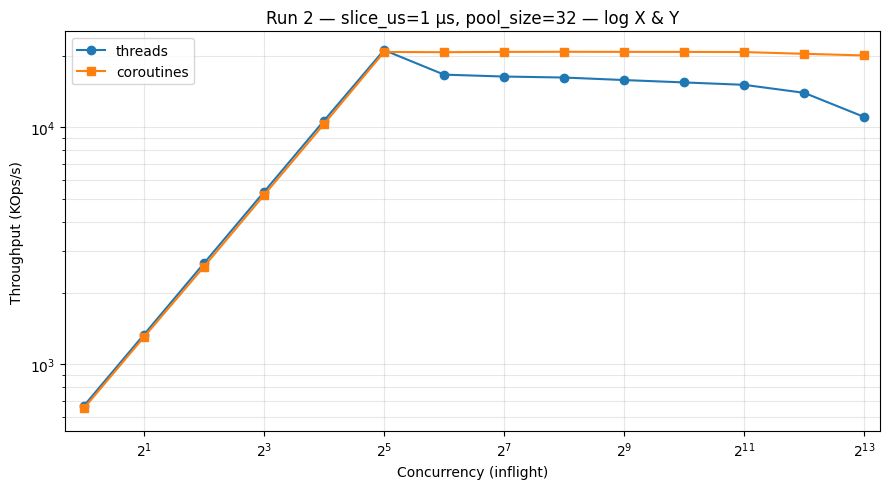

In [35]:
plot_threads_vs_coro(
    j2_threads,
    j2_coro,
    title=f"Run 2 — slice_us={SLICE_US_2} µs, pool_size={POOL_SIZE}",
)
plot_threads_vs_coro_logx_liny(
    j2_threads,
    j2_coro,
    title=f"Run 2 — slice_us={SLICE_US_2} µs, pool_size={POOL_SIZE}",
)
plot_threads_vs_coro_logx(
    j2_threads,
    j2_coro,
    title=f"Run 2 — slice_us={SLICE_US_2} µs, pool_size={POOL_SIZE}",
)

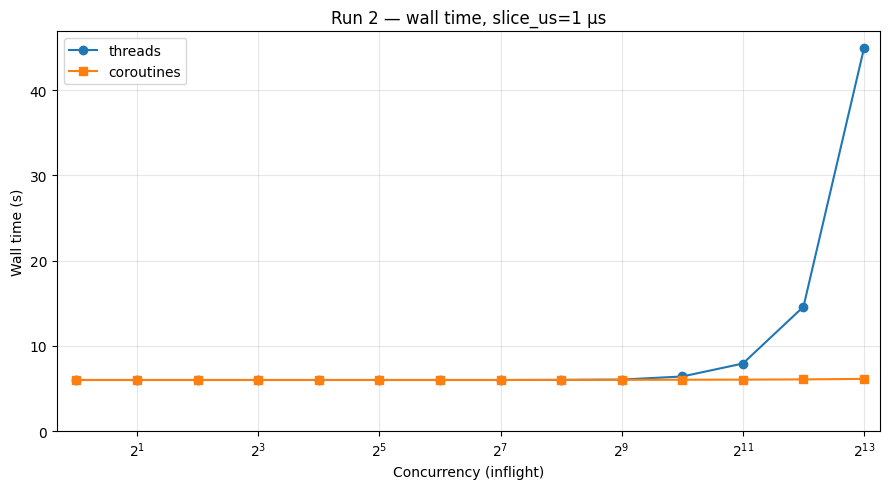

In [36]:
plot_wall_time(
    j2_threads,
    j2_coro,
    title=f"Run 2 — wall time, slice_us={SLICE_US_2} µs",
)

## 6. Slice-size comparison (log-log)

Compares **Run 1** (`SLICE_US_1`) and **Run 2** (`SLICE_US_2`) on log-log axes: one chart for coroutines and one for threads. Run sections **4** and **5** first.

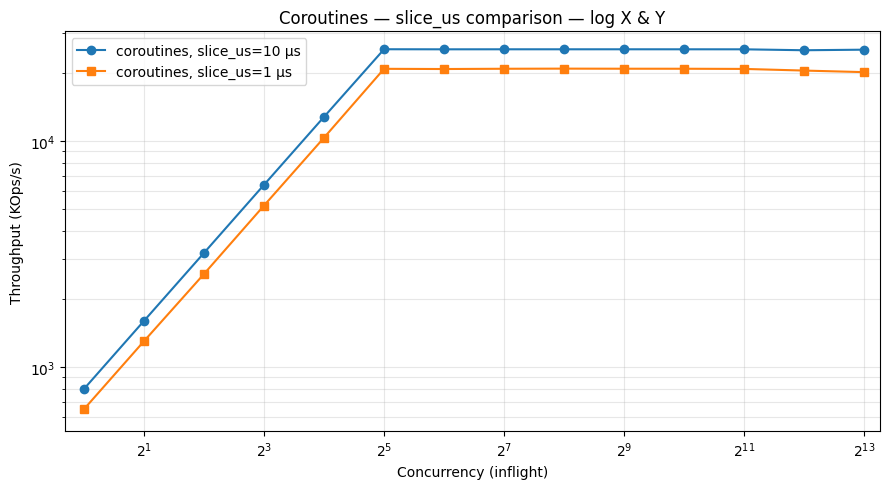

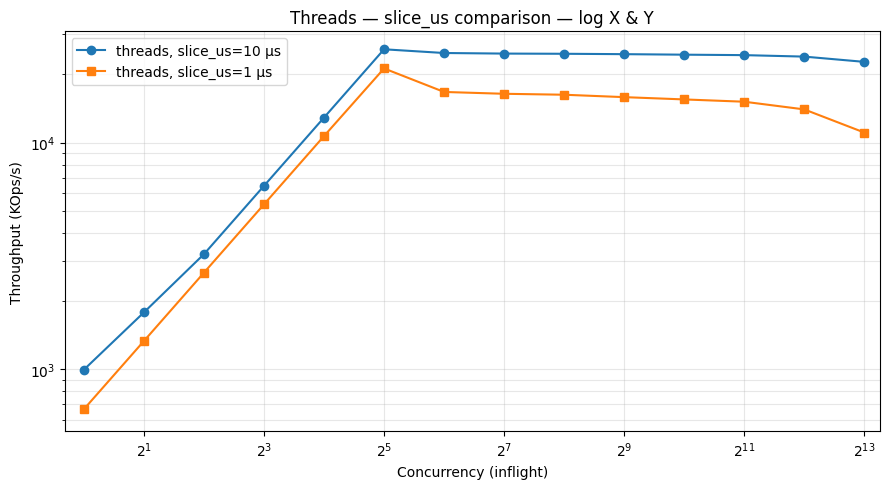

In [37]:
try:
    SLICE_US_1
    SLICE_US_2
    j1_coro
    j2_coro
    j1_threads
    j2_threads
except NameError as e:
    raise RuntimeError(
        "Run sections 4 and 5 first (benchmarks for all slice_us values)."
    ) from e

x1_coro, _ = series_kops(j1_coro)
x2_coro, _ = series_kops(j2_coro)
x1_threads, _ = series_kops(j1_threads)
x2_threads, _ = series_kops(j2_threads)
if not (x1_coro == x2_coro) or not (x1_threads == x2_threads):
    raise RuntimeError(
        "All runs must use the same concurrency points for slice-size comparison. "
        "Ensure all runs use the shared FROM_N and TO_N constants."
    )

plot_slice_compare_loglog(
    [
        (j1_coro, f"coroutines, slice_us={SLICE_US_1} µs"),
        (j2_coro, f"coroutines, slice_us={SLICE_US_2} µs"),
    ],
    title="Coroutines — slice_us comparison",
)

plot_slice_compare_loglog(
    [
        (j1_threads, f"threads, slice_us={SLICE_US_1} µs"),
        (j2_threads, f"threads, slice_us={SLICE_US_2} µs"),
    ],
    title="Threads — slice_us comparison",
)